In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

df = pd.read_csv('/content/Dengue2.csv')
df1= df[['Date','effected-people-per-day']]
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%y')
df1['year']=df1['Date'].dt.year
df1['month']=df1['Date'].dt.month
df1['effected-people-per-day'] = df1['effected-people-per-day'].ffill()
df1


/tmp/ipykernel_9934/888443862.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%y')
/tmp/ipykernel_9934/888443862.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['year']=df1['Date'].dt.year
/tmp/ipykernel_9934/888443862.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

,Date,effected-people-per-day,year,month
0,2022-01-01,4.0,2022,1
1,2022-01-02,11.0,2022,1
2,2022-01-03,29.0,2022,1
3,2022-01-04,4.0,2022,1
4,2022-01-05,4.0,2022,1
...,...,...,...,...
1091,2024-12-27,53.0,2024,12
1092,2024-12-28,104.0,2024,12
1093,2024-12-29,148.0,2024,12
1094,2024-12-30,114.0,2024,12


In [ ]:
pd.set_option('display.max_rows', None)
df1

,Date,effected-people-per-day,year,month
0,2022-01-01,4.0,2022,1
1,2022-01-02,11.0,2022,1
2,2022-01-03,29.0,2022,1
3,2022-01-04,4.0,2022,1
4,2022-01-05,4.0,2022,1
5,2022-01-06,9.0,2022,1
6,2022-01-07,1.0,2022,1
7,2022-01-08,2.0,2022,1
8,2022-01-09,7.0,2022,1
9,2022-01-10,3.0,2022,1


In [2]:
df1['m1'] = ((df1['month']-1)//2)+1
df1['p1']=df1['year'].astype(str)+'_P'+df1['m1'].astype(str)
df1['m2'] = ((df1['month']-1)//3)+1
df1['p2']=df1['year'].astype(str)+'_W'+df1['m2'].astype(str)
df1['m3'] = ((df1['month']-1)//4)+1
df1['p3']=df1['year'].astype(str)+'_S'+df1['m3'].astype(str)
df1

/tmp/ipykernel_9934/607974713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m1'] = ((df1['month']-1)//2)+1
/tmp/ipykernel_9934/607974713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['p1']=df1['year'].astype(str)+'_P'+df1['m1'].astype(str)
/tmp/ipykernel_9934/607974713.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

,Date,effected-people-per-day,year,month,m1,p1,m2,p2,m3,p3
0,2022-01-01,4.0,2022,1,1,2022_P1,1,2022_W1,1,2022_S1
1,2022-01-02,11.0,2022,1,1,2022_P1,1,2022_W1,1,2022_S1
2,2022-01-03,29.0,2022,1,1,2022_P1,1,2022_W1,1,2022_S1
3,2022-01-04,4.0,2022,1,1,2022_P1,1,2022_W1,1,2022_S1
4,2022-01-05,4.0,2022,1,1,2022_P1,1,2022_W1,1,2022_S1
...,...,...,...,...,...,...,...,...,...,...
1091,2024-12-27,53.0,2024,12,6,2024_P6,4,2024_W4,3,2024_S3
1092,2024-12-28,104.0,2024,12,6,2024_P6,4,2024_W4,3,2024_S3
1093,2024-12-29,148.0,2024,12,6,2024_P6,4,2024_W4,3,2024_S3
1094,2024-12-30,114.0,2024,12,6,2024_P6,4,2024_W4,3,2024_S3


In [3]:
for period in df1['p2'].unique():
  data = df1[df1['p2']==period]
  print(data)

         Date  effected-people-per-day  year  month  m1       p1  m2       p2  \
0  2022-01-01                      4.0  2022      1   1  2022_P1   1  2022_W1   
1  2022-01-02                     11.0  2022      1   1  2022_P1   1  2022_W1   
2  2022-01-03                     29.0  2022      1   1  2022_P1   1  2022_W1   
3  2022-01-04                      4.0  2022      1   1  2022_P1   1  2022_W1   
4  2022-01-05                      4.0  2022      1   1  2022_P1   1  2022_W1   
..        ...                      ...   ...    ...  ..      ...  ..      ...   
85 2022-03-27                      1.0  2022      3   2  2022_P2   1  2022_W1   
86 2022-03-28                      0.0  2022      3   2  2022_P2   1  2022_W1   
87 2022-03-29                      2.0  2022      3   2  2022_P2   1  2022_W1   
88 2022-03-30                      4.0  2022      3   2  2022_P2   1  2022_W1   
89 2022-03-31                      0.0  2022      3   2  2022_P2   1  2022_W1   

    m3       p3  
0    1  2

In [4]:
def visibility_graph(data):
    n = len(data)
    graph = nx.Graph()
    graph.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            visible = True
            for k in range(i + 1, j):
                y_k = data[i] + (data[j] - data[i]) * (k - i) / (j - i)
                if data[k] >= y_k:
                    visible = False
                    break
            if visible:
                graph.add_edge(i, j)
    return graph
    #n = len(data)
    #G = nx.visibility_graph(data)
    #return G

[4.0, 11.0, 29.0, 4.0, 4.0, 9.0, 1.0, 2.0, 7.0, 3.0, 3.0, 14.0, 3.0, 1.0, 5.0, 2.0, 2.0, 4.0, 7.0, 1.0, 0.0, 0.0, 2.0, 3.0, 1.0, 0.0, 1.0, 2.0, 0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 1.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 1.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, 1.0, 1.0, 0.0, 2.0, 4.0, 0.0]
90
319


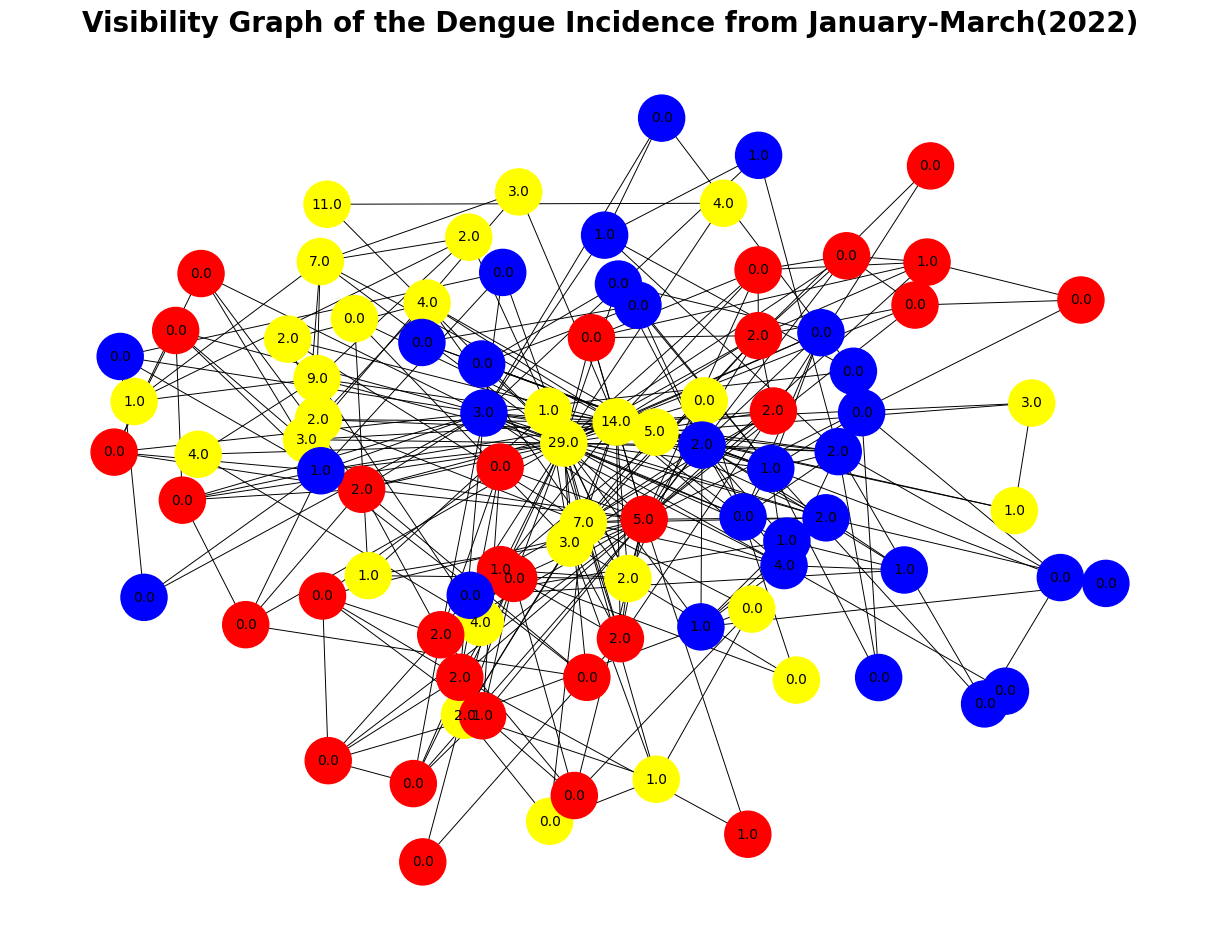

[270.0, 509.0, 436.0, 678.0, 584.0, 661.0, 182.0, 820.0, 836.0, 889.0, 1054.0, 1246.0, 1239.0, 449.0, 1623.0, 1424.0, 1589.0, 1533.0, 1792.0, 1755.0, 896.0, 2242.0, 2292.0, 2293.0, 2418.0, 2653.0, 2361.0, 1503.0, 2202.0, 2731.0, 2694.0, 2584.0, 2711.0, 2589.0, 1757.0, 2495.0, 2764.0, 2751.0, 2742.0, 2844.0, 2959.0, 2046.0, 2432.0, 2905.0, 2480.0, 1984.0, 2149.0, 2288.0, 1565.0, 1983.0, 2134.0, 2197.0, 2168.0, 2070.0, 2201.0, 1594.0, 1960.0, 2327.0, 2331.0, 2291.0, 2367.0, 2308.0, 1534.0, 2352.0, 2608.0, 2823.0, 2782.0, 2115.0, 2689.0, 1876.0, 2748.0, 2993.0, 2944.0, 2956.0, 2944.0, 2663.0, 2129.0, 2598.0, 3122.0, 3084.0, 3027.0, 3015.0, 2889.0, 2153.0, 2865.0, 3008.0, 3033.0, 3123.0, 2950.0, 2357.0, 1793.0, 2425.0]
92
263


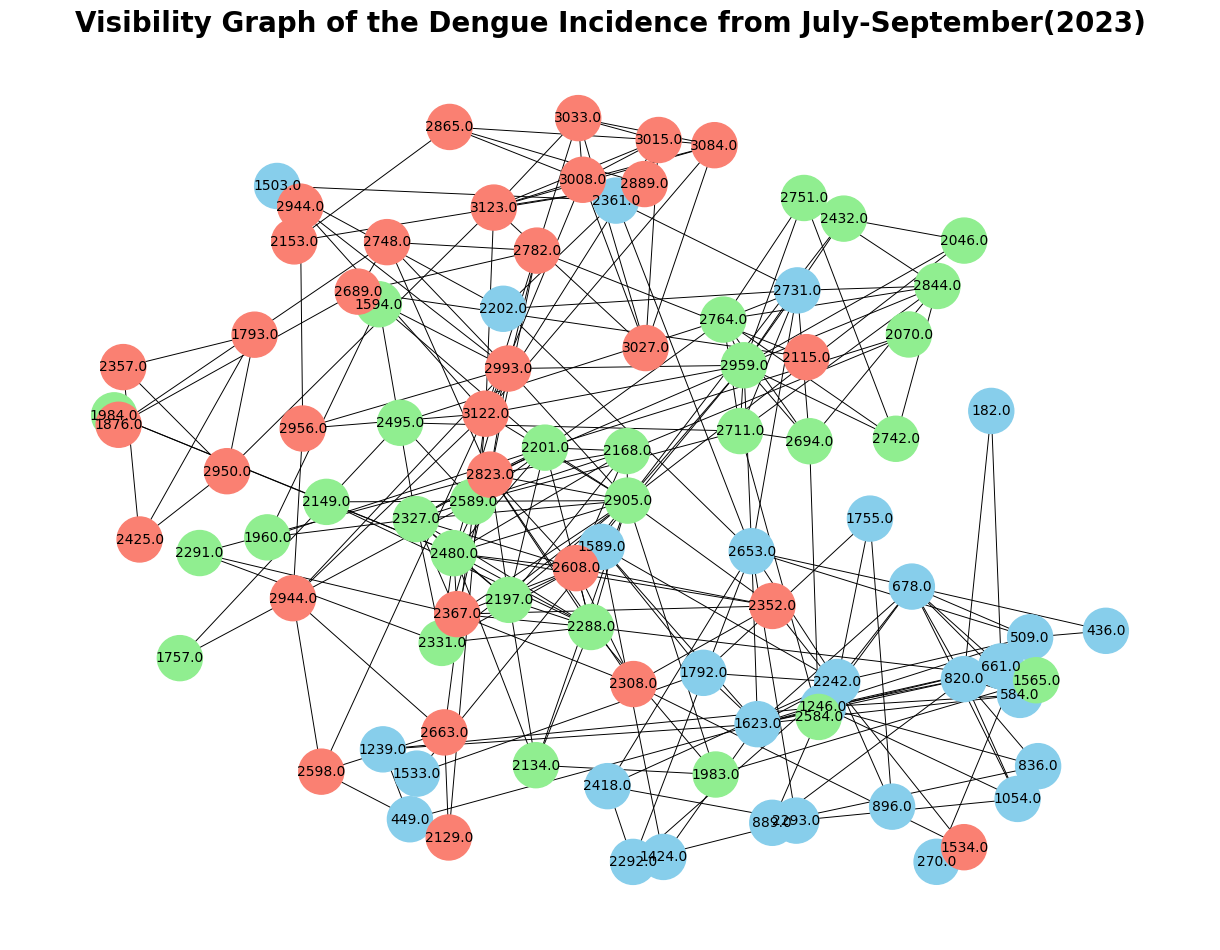

[51.0, 49.0, 61.0, 32.0, 22.0, 26.0, 86.0, 63.0, 88.0, 79.0, 103.0, 25.0, 75.0, 155.0, 112.0, 110.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 174.0, 263.0, 148.0, 98.0, 272.0, 226.0, 150.0, 176.0, 197.0, 80.0, 154.0, 211.0, 35.0, 192.0, 159.0, 181.0, 34.0, 204.0, 202.0, 285.0, 215.0, 233.0, 228.0, 50.0, 237.0, 334.0, 265.0, 249.0, 296.0, 217.0, 78.0, 303.0, 319.0, 105.0, 364.0, 326.0, 269.0, 153.0, 346.0, 478.0, 289.0, 335.0, 385.0, 358.0, 118.0, 403.0, 463.0, 615.0, 534.0, 465.0, 561.0, 196.0, 548.0, 486.0, 267.0, 872.0, 865.0, 887.0, 299.0, 843.0, 926.0, 866.0, 801.0, 854.0, 829.0, 321.0, 860.0, 1221.0, 1152.0]
92
303


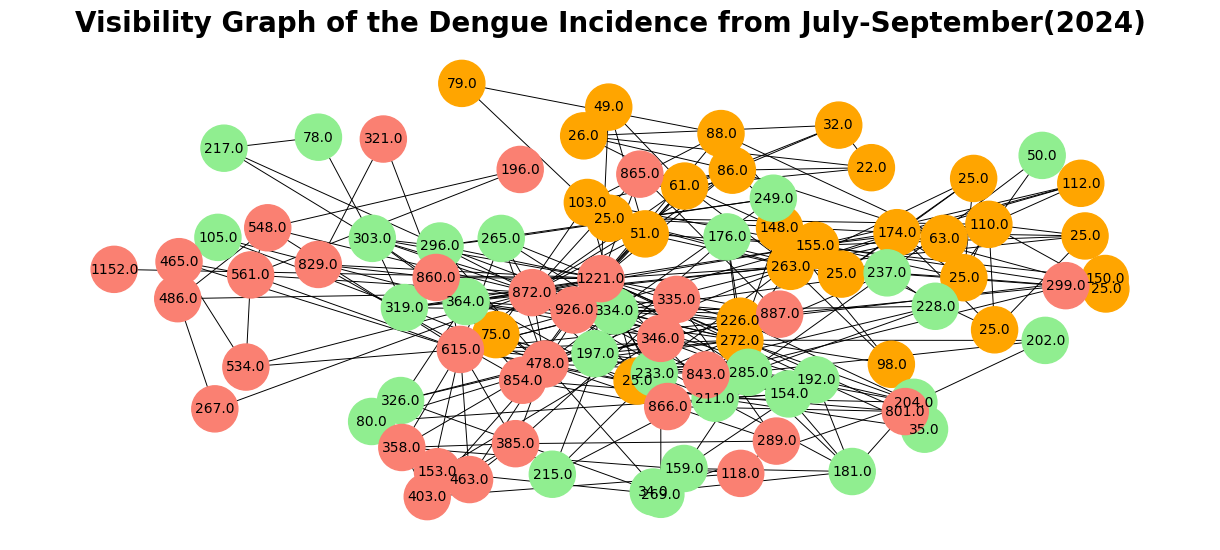

In [7]:

#year of 2022

max_2022 = df1[df1['p2']=='2022_W1']['effected-people-per-day'].tolist()
print(max_2022)
graph1_2022 = visibility_graph(max_2022)
print(graph1_2022.number_of_nodes())
print(graph1_2022.number_of_edges())

n=len(max_2022)

for i, value in enumerate(max_2022):
    graph1_2022.add_node(i, label=value)

half = n//3
colors=['yellow' if i<half else 'red' if i<2*half else 'blue' for i in range(n)]

plt.figure(figsize=(12,9))
pos = nx.spring_layout(graph1_2022, k=0.7)
#node_sizes_2022 = [max_data_2022[node] + 70 for node in graph_max_2022.nodes()]
nx.draw(graph1_2022, pos, with_labels= True,labels=nx.get_node_attributes(graph1_2022,'label'), node_size=1100, node_color=colors, font_size=10, font_color='black', edge_color='black', width=0.7 )
plt.title("Visibility Graph of the Dengue Incidence from January-March(2022)", fontsize=20, fontweight='bold')
plt.show()


#year of 2023
max_data_2022 = df1[df1['p2']=='2023_W3']['effected-people-per-day'].tolist()
n=len(max_data_2022)


print(max_data_2022)
graph_max_2022 = visibility_graph(max_data_2022)
print(graph_max_2022.number_of_nodes())
print(graph_max_2022.number_of_edges())

#for node in graph_max_2022.nodes():
    #print("Node:", node,
          #"Value:", graph_max_2022.nodes[node]['value'],
          #"Degree:", graph_max_2022.degree(node),
          #"Neighbors:", list(graph_max_2022.neighbors(node)))

for i, value in enumerate(max_data_2022):
    graph_max_2022.add_node(i, label=value)

half = n//3
colors=['skyblue' if i<half else 'lightgreen' if i<2*half else 'salmon' for i in range(n)]

plt.figure(figsize=(12,9))
pos = nx.spring_layout(graph_max_2022, k=0.7)

nx.draw(graph_max_2022, pos, with_labels= True, labels=nx.get_node_attributes(graph_max_2022,'label'),node_color=colors, node_size=1050, font_size=10, font_color='black', edge_color='black', width=0.7 )
plt.title("Visibility Graph of the Dengue Incidence from July-September(2023)", fontsize=20, fontweight='bold')
plt.show()

#year of 2024
data_2022 = df1[df1['p2']=='2024_W3']['effected-people-per-day'].tolist()
print(data_2022)
graph_2022 = visibility_graph(data_2022)
n=len(data_2022)
print(graph_2022.number_of_nodes())
print(graph_2022.number_of_edges())

for i, value in enumerate(data_2022):
    graph_2022.add_node(i, label=value)

half = n//3
colors=['orange' if i<half else 'lightgreen' if i<2*half else 'salmon' for i in range(n)]

plt.figure(figsize=(12,5))
pos = nx.spring_layout(graph_2022, k=0.7)
#node_sizes_2022 = [max_data_2022[node] + 70 for node in graph_max_2022.nodes()]
nx.draw(graph_2022, pos, with_labels= True,labels=nx.get_node_attributes(graph_2022,'label'), node_size=1100, node_color=colors, font_size=10, font_color='black', edge_color='black', width=0.7 )
#plt.title("Visibility Graph of the Dengue Incidence from July-September(2024)")
plt.title("Visibility Graph of the Dengue Incidence from July-September(2024)", fontsize=20, fontweight='bold')
plt.show()

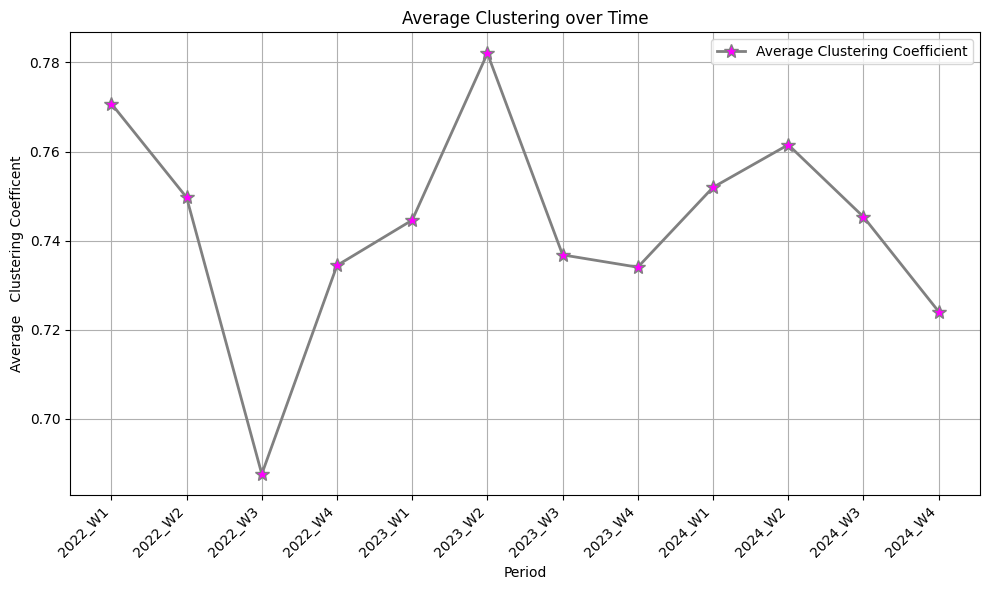

In [ ]:
def clustering_coefficient(data):
    vis_graph = visibility_graph(data)
    if vis_graph.number_of_nodes() > 0:
        clust_coeff = nx.average_clustering(vis_graph)
        return clust_coeff

        #return sum(clust_coeff.values())/len(clust_coeff)
    else:
        return 0

avc1 = []

for period in df1['p2'].unique():
  data = df1[df1['p2']==period]['effected-people-per-day'].tolist()
  #print(data)
  avc1.append(clustering_coefficient(data))


plt.figure(figsize=(10,6))
plt.plot(range(len(df1['p2'].unique())), avc1, markerfacecolor='magenta', markersize=10, marker='*', linewidth=2, linestyle='-', color='gray', label='Average Clustering Coefficient')
plt.xlabel('Period')
plt.ylabel('Average   Clustering Coefficent') # Corrected y-axis label
plt.title('Average Clustering over Time')
plt.xticks(range(len(df1['p2'].unique())), df1['p2'].unique())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.legend(loc = 'upper right',ncol=3)  # Display legend
plt.show()